In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [5]:
Data = pd.read_csv("customer_shopping.csv")
Data.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN500000,CUST001440,2023-07-22,52,Other,Indore,Offline,In-Store Purchase,Clothing,Jeans,...,Standard Day,0,N/A (Offline),0,No,Credit Card,5,Not Returned,2,Quarterly
1,TXN500001,CUST002326,2023-01-16,19,Female,Bhubaneswar,Online,Ajio,Clothing,Jacket,...,Standard Day,0,Express,1,No,Debit Card,4,Returned,3,Quarterly
2,TXN500002,CUST002680,2023-01-24,40,Male,Bangalore,Online,Myntra,Clothing,Saree,...,Standard Day,0,Standard,7,Yes,Cash on Delivery,4,Not Returned,13,Monthly
3,TXN500003,CUST001098,2024-09-06,46,Female,Ahmedabad,Offline,In-Store Purchase,Clothing,Jeans,...,Standard Day,0,N/A (Offline),0,No,UPI,3,Not Returned,1,Rarely
4,TXN500004,CUST003158,2023-10-18,62,Female,Pune,Online,Flipkart,Accessories,Belt,...,Standard Day,0,Standard,6,Yes,UPI,3,Not Returned,3,Quarterly


In [4]:
Data.isnull().sum()

Transaction ID            0
Customer ID               0
Purchase Date             0
Age                       0
Gender                    0
Location                  0
Online/Offline            0
Online Store              0
Category                  0
Item Purchased            0
Brand                     0
Color                     0
Size                      0
Quantity                  0
Purchase Amount (₹)       0
Discount (%)              0
Festival/Sale             0
Shipping Charge (₹)       0
Delivery Speed            0
Delivery Time (Days)      0
Subscription Status       0
Payment Method            0
Review Rating             0
Return Status             0
Previous Purchases        0
Frequency of Purchases    0
dtype: int64

In [9]:
print(Data.dtypes)

Transaction ID            object
Customer ID               object
Purchase Date             object
Age                        int64
Gender                    object
Location                  object
Online/Offline            object
Online Store              object
Category                  object
Item Purchased            object
Brand                     object
Color                     object
Size                      object
Quantity                   int64
Purchase Amount (₹)        int64
Discount (%)               int64
Festival/Sale             object
Shipping Charge (₹)        int64
Delivery Speed            object
Delivery Time (Days)       int64
Subscription Status       object
Payment Method            object
Review Rating              int64
Return Status             object
Previous Purchases         int64
Frequency of Purchases    object
dtype: object


In [13]:
Data.describe()

,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,41.095400,1.425900,6467.694500,8.704500,20.472500,2.580500,3.47960,14.678100
std,13.537475,0.725921,8777.617508,7.278893,28.954345,2.466603,0.87319,15.955574
min,18.000000,1.000000,107.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,29.000000,1.000000,1659.000000,4.000000,0.000000,0.000000,3.00000,2.000000
50%,41.000000,1.000000,3491.000000,8.000000,0.000000,2.000000,4.00000,9.000000
75%,53.000000,2.000000,7544.250000,12.000000,40.000000,5.000000,4.00000,23.000000
max,64.000000,4.000000,113920.000000,69.000000,99.000000,7.000000,5.00000,85.000000


In [7]:
print(Data['Online Store'].max())

Nykaa


.max() not worth applying on an object type field , instead value_counts() is more preferrable as the current one is returning max based on (A-Z)

In [12]:
print(Data['Category'].max())

Footwear


In [ ]:
sns.histplot(Data['Age'],kde=True,bins=20)

In [16]:
print(Data['Age'].skew())


-0.01330411390689294


As we can see the age column is having its dataset skewed more on the left side because the skew value is lying on the negative side , therefore the data is approximately symmetric as the skew value is near to zero , if it were beyond -1 then the data set would have been considered highky skewed

In [18]:
print(Data['Age'].kurtosis())

-1.1865459234685698


Kurtosis value on the nagtiveside and <3 indicates flatter curve and thin tail , making our dataset highky unlikely to display extreme unexpected values 

In [20]:
print(Data['Online/Offline'].value_counts())

Online/Offline
Online     7417
Offline    2583
Name: count, dtype: int64


In [21]:
print(Data['Online Store'].value_counts())

Online Store
In-Store Purchase    2583
Meesho               1277
Ajio                 1276
Amazon               1229
Myntra               1218
Flipkart             1212
Nykaa                1205
Name: count, dtype: int64


In [23]:
Popular =  Data['Category'].value_counts()
Popular 

Category
Clothing       5004
Footwear       3395
Accessories    1601
Name: count, dtype: int64

In [26]:
Item =  Data['Item Purchased'].value_counts()
Item 

Item Purchased
Kurta            870
Running Shoes    861
Saree            846
Sneakers         817
Jacket           676
T-shirt          645
Shorts           604
Hoodie           417
Sandals          371
Heels            352
Slippers         346
Boots            329
Formal Shoes     319
Backpack         264
Jeans            250
Bag              244
Socks            240
Trousers         239
Shirt            232
Sunglasses       232
Dress            225
Belt             221
Cap              202
Wallet           198
Name: count, dtype: int64

In [34]:
print(Data['Purchase Amount (₹)'].kurtosis())

22.80684680354781


In [32]:
Purch_Dist = Data['Purchase Amount (₹)'].skew()
Purch_Dist

np.float64(3.8529692765096892)

<Axes: xlabel='Purchase Amount (₹)', ylabel='Count'>

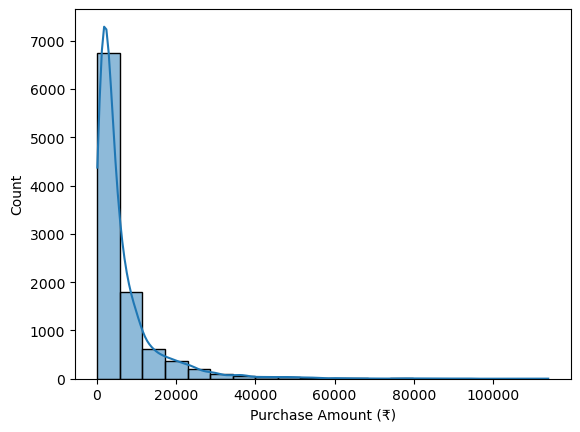

In [33]:
sns.histplot(Data['Purchase Amount (₹)'],kde=True,bins=20)

In the distribution graph and histogram we can clearly see that the data set is skewed on the right side in high proportion.
Skew value also greater than 1 i.e , 3 and on the positive side . On the other hand the kurtosis value of 22.806 indicating a sharp peak and a flatter tail clearly visible in the graph also .

This concludes that the Purchase Amount field in our dataset is highly prone to Outliers !!!

In [36]:
print(Data['Review Rating'].value_counts())

Review Rating
4    4027
3    3613
2    1181
5    1077
1     102
Name: count, dtype: int64


In [38]:
print(Data['Review Rating'].mean())

3.4796


In [42]:
Mat = Data.corr(numeric_only=True)
Mat


,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
Age,1.000000,-0.009600,0.003135,0.010799,0.004222,-0.002991,0.019353,0.003176
Quantity,-0.009600,1.000000,0.369169,0.000124,-0.008709,-0.001137,0.003847,0.003419
Purchase Amount (₹),0.003135,0.369169,1.000000,0.017517,-0.001033,0.001521,0.132791,0.001391
Discount (%),0.010799,0.000124,0.017517,1.000000,-0.022761,-0.036890,0.008721,-0.010011
Shipping Charge (₹),0.004222,-0.008709,-0.001033,-0.022761,1.000000,0.252737,-0.058034,0.003326
Delivery Time (Days),-0.002991,-0.001137,0.001521,-0.036890,0.252737,1.000000,-0.326249,0.002248
Review Rating,0.019353,0.003847,0.132791,0.008721,-0.058034,-0.326249,1.000000,-0.005227
Previous Purchases,0.003176,0.003419,0.001391,-0.010011,0.003326,0.002248,-0.005227,1.000000


<Axes: xlabel='Delivery Time (Days)', ylabel='Review Rating'>

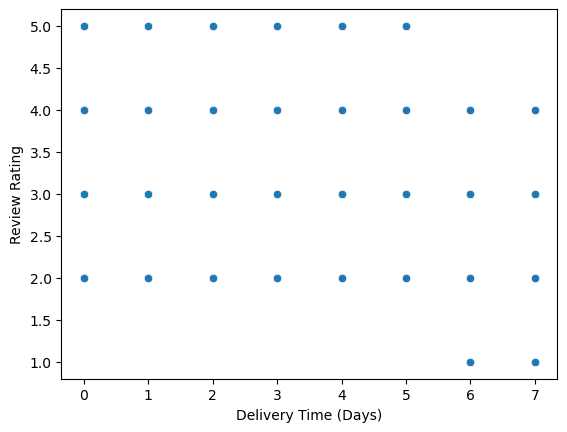

In [45]:
sns.scatterplot(x='Delivery Time (Days)',y='Review Rating',data=Data)

 In the scatter plot and the correlation matrix we can clearly see that , Delivery time and Review Ratings are having a negative correlation , indicating as the delivery time increases the user's review rating drops . This directly shows Delivery time is affecting the review ratings heavily and one more observation is that user does not have major issue between a delivery period of 3-5 days but it faces dissatisfaction once he time increases from 5 days 

In [48]:
Data.groupby('Online Store')['Review Rating'].mean().mean()

np.float64(3.4515476557150664)

In [54]:
Data.groupby('Delivery Time (Days)')['Review Rating'].mean()

Delivery Time (Days)
0    3.657911
1    3.646098
2    3.692019
3    3.678571
4    3.622788
5    3.623786
6    2.681015
7    2.715508
Name: Review Rating, dtype: float64

In [55]:
Return_Rate = Data.groupby('Online/Offline')['Return Status'].value_counts(normalize=True)
Return_Rate

Online/Offline  Return Status
Offline         Not Returned     0.837011
                Returned         0.162989
Online          Not Returned     0.820682
                Returned         0.179318
Name: proportion, dtype: float64

Here it is clearly displayed that the online platforms have higher return status than the offline stores 

In [100]:
print(Data.groupby('Payment Method')['Purchase Amount (₹)'].sum().sort_values())

Payment Method
Net Banking          2304268
Wallet               2381286
Cash                 3643428
Cash on Delivery     6847375
Debit Card           9669888
Credit Card         12644635
UPI                 27186065
Name: Purchase Amount (₹), dtype: int64


In the above dataset we can see that Payment method associated wiht the most Purchase amount is UPI then Credit Card and at the 3rd place Debit Card 

In [63]:
print(Data.groupby('Gender')['Purchase Amount (₹)'].mean())

Gender
Female    6566.050217
Male      6337.455115
Other     6866.355795
Name: Purchase Amount (₹), dtype: float64


In [101]:
print(Data.groupby('Location')['Purchase Amount (₹)'].sum().sort_values())

Location
Hyderabad        2276445
Surat            2688973
Kochi            2802281
Pune             2903318
Delhi            2903570
Indore           2919026
Chandigarh       2920971
Ahmedabad        3124247
Nagpur           3126739
Gurgaon          3200230
Visakhapatnam    3211221
Bhubaneswar      3231826
Jaipur           3296945
Mumbai           3309379
Patna            3399737
Chennai          3427610
Bangalore        3683168
Kolkata          3714993
Noida            4194429
Lucknow          4341837
Name: Purchase Amount (₹), dtype: int64


Lucknow is the city with the highest total revenue -  43,41,837 generated from this single state then comes Noida with  41,94,429 Ruppees

In [98]:
print(Data.groupby('Customer ID')['Purchase Amount (₹)'].sum().sort_values())

Customer ID
CUST000698       179
CUST001572       189
CUST001234       234
CUST001349       264
CUST000309       307
               ...  
CUST003286    126587
CUST000204    130214
CUST001745    135120
CUST001269    159200
CUST001753    187570
Name: Purchase Amount (₹), Length: 3291, dtype: int64


Cust 001745 is the highest value customer by Purchase Amount that is 1,87,570

In [74]:
print(Data.groupby('Category')['Return Status'].value_counts(normalize=True).sort_values())

Category     Return Status
Accessories  Returned         0.101187
Clothing     Returned         0.188050
Footwear     Returned         0.190869
             Not Returned     0.809131
Clothing     Not Returned     0.811950
Accessories  Not Returned     0.898813
Name: proportion, dtype: float64


In [73]:
print(Data.groupby('Brand')['Return Status'].value_counts(normalize=True).sort_values())

Brand           Return Status
Tommy Hilfiger  Returned         0.053254
Levis           Returned         0.093426
Fastrack        Returned         0.132258
Puma            Returned         0.135089
FabIndia        Returned         0.141667
Hush Puppies    Returned         0.146341
Zara            Returned         0.156805
Nike            Returned         0.157005
H&M             Returned         0.166667
Biba            Returned         0.166966
Wildcraft       Returned         0.172881
Adidas          Returned         0.173703
Allen Solly     Returned         0.186047
Roadster        Returned         0.231660
HRX             Returned         0.243114
Bata            Returned         0.247216
Max             Returned         0.265740
                Not Returned     0.734260
Bata            Not Returned     0.752784
HRX             Not Returned     0.756886
Roadster        Not Returned     0.768340
Allen Solly     Not Returned     0.813953
Adidas          Not Returned     0.826297
Wild

<Axes: xlabel='Delivery Speed', ylabel='Shipping Charge (₹)'>

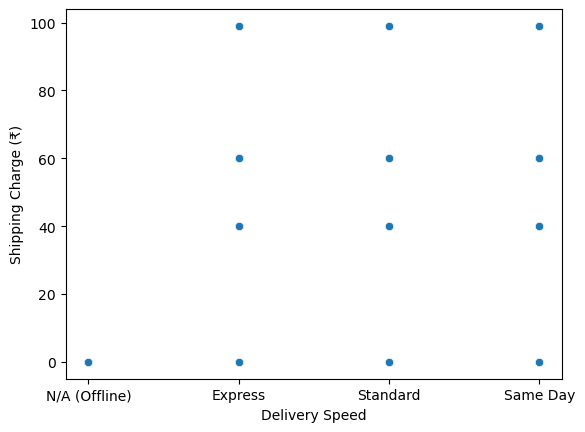

In [78]:
sns.scatterplot(x='Delivery Speed' , y ='Shipping Charge (₹)' , data = Data)

<Axes: xlabel='Delivery Speed', ylabel='Shipping Charge (₹)'>

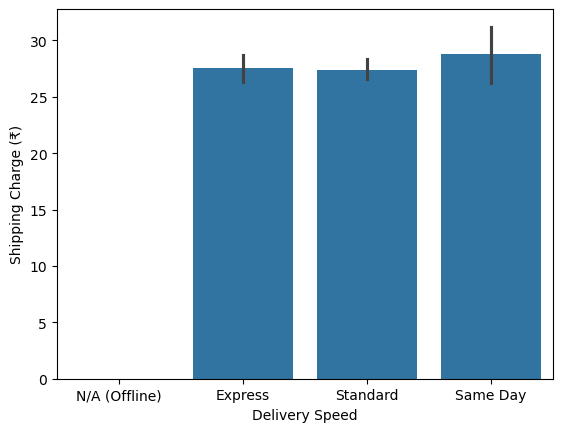

In [79]:
sns.barplot(x='Delivery Speed', y='Shipping Charge (₹)', data=Data)

<Axes: xlabel='Purchase Date', ylabel='Purchase Amount (₹)'>

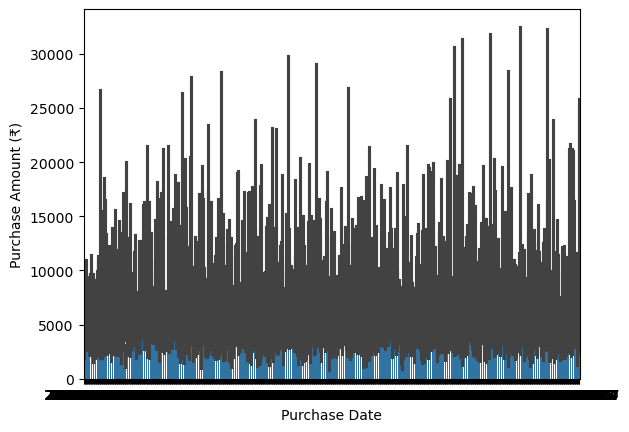

In [88]:
sns.barplot(x='Purchase Date' , y='Purchase Amount (₹)' , data=Data)

In [96]:
print(Data.groupby('Frequency of Purchases')['Purchase Amount (₹)'].value_counts())

Frequency of Purchases  Purchase Amount (₹)
Fortnightly             510                    3
                        754                    3
                        1083                   3
                        1264                   3
                        1377                   3
                                              ..
Weekly                  60700                  1
                        63441                  1
                        76731                  1
                        89178                  1
                        92578                  1
Name: count, Length: 9033, dtype: int64


Sales trend over different slices in the year 

In [95]:
print(Data.groupby('Festival/Sale')['Discount (%)'].mean().sort_values())

Festival/Sale
Standard Day                     6.891794
In-Store Festival Offer         19.400911
Independence Day Sale           24.338710
Republic Day Sale               25.125000
Diwali Sale                     32.887097
Nykaa Pink Friday               37.700000
Amazon Great Indian Festival    39.625000
Big Billion Days                41.578947
Myntra End of Reason Sale       45.562500
Name: Discount (%), dtype: float64


Here it is clearly displayed that during the Festival/Sales the discounts see major peak with the most discount offered on the Myntra End of Season Sale

In [102]:
Data.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN500000,CUST001440,2023-07-22,52,Other,Indore,Offline,In-Store Purchase,Clothing,Jeans,...,Standard Day,0,N/A (Offline),0,No,Credit Card,5,Not Returned,2,Quarterly
1,TXN500001,CUST002326,2023-01-16,19,Female,Bhubaneswar,Online,Ajio,Clothing,Jacket,...,Standard Day,0,Express,1,No,Debit Card,4,Returned,3,Quarterly
2,TXN500002,CUST002680,2023-01-24,40,Male,Bangalore,Online,Myntra,Clothing,Saree,...,Standard Day,0,Standard,7,Yes,Cash on Delivery,4,Not Returned,13,Monthly
3,TXN500003,CUST001098,2024-09-06,46,Female,Ahmedabad,Offline,In-Store Purchase,Clothing,Jeans,...,Standard Day,0,N/A (Offline),0,No,UPI,3,Not Returned,1,Rarely
4,TXN500004,CUST003158,2023-10-18,62,Female,Pune,Online,Flipkart,Accessories,Belt,...,Standard Day,0,Standard,6,Yes,UPI,3,Not Returned,3,Quarterly


In [103]:
Data[Data['Online/Offline']=='Offline']['Delivery Time (Days)'].unique()

array([0])

In [104]:
print(Data['Customer ID'].value_counts().describe())
print((Data['Customer ID'].value_counts() > 1).sum(), "customers have multiple transactions")

count    3291.000000
mean        3.038590
std         1.616227
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: count, dtype: float64
2693 customers have multiple transactions


In [107]:
Data.head(2)

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN500000,CUST001440,2023-07-22,52,Other,Indore,Offline,In-Store Purchase,Clothing,Jeans,...,Standard Day,0,N/A (Offline),0,No,Credit Card,5,Not Returned,2,Quarterly
1,TXN500001,CUST002326,2023-01-16,19,Female,Bhubaneswar,Online,Ajio,Clothing,Jacket,...,Standard Day,0,Express,1,No,Debit Card,4,Returned,3,Quarterly


In [120]:
categorical_cols = ['Online/Offline', 'Location']
numeric_cols = ['Delivery Time (Days)', 'Age']

In [111]:
X = Data[['Delivery Time (Days)', 'Online/Offline', 'Age', 'Location']]
y = Data['Payment Method']

In [134]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', SimpleImputer(strategy='constant', fill_value=0), numeric_cols)
    ]
)

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [136]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [141]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train_enc, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [142]:
y_pred = model.predict(X_test_enc)

In [143]:
print(confusion_matrix(y_test, y_pred))

[[  0   0   0   0   0 107   0]
 [  0   0   0   0   0 218   0]
 [  0   0   0   2   0 392   1]
 [  0   1   0   1   0 282   0]
 [  0   0   0   0   0  71   0]
 [  4   0   0   5   0 846   1]
 [  0   0   0   0   0  69   0]]


In [144]:
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

            Cash       0.00      0.00      0.00       107
Cash on Delivery       0.00      0.00      0.00       218
     Credit Card       0.00      0.00      0.00       395
      Debit Card       0.12      0.00      0.01       284
     Net Banking       0.00      0.00      0.00        71
             UPI       0.43      0.99      0.60       856
          Wallet       0.00      0.00      0.00        69

        accuracy                           0.42      2000
       macro avg       0.08      0.14      0.09      2000
    weighted avg       0.20      0.42      0.26      2000



D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


"Payment Method could not be reliably predicted using Previous Purchases, Delivery Time, Online/Offline, Age, or Location — the model consistently defaulted to majority-class prediction (UPI, ~43% base rate). This suggests payment method choice is driven by factors not captured in this dataset, such as banking access or platform-level incentives."

Now , Conducting a model to predict the return rate based on different parameters

In [145]:
features = ['Category', 'Brand', 'Online/Offline', 'Discount (%)', 
            'Delivery Speed', 'Delivery Time (Days)', 'Payment Method', 
            'Size', 'Age', 'Gender']

X = Data[features]
y = Data['Return Status']

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [147]:
categorical_cols = ['Category', 'Brand', 'Online/Offline', 'Delivery Speed', 
                     'Payment Method', 'Size', 'Gender']
numeric_cols = ['Discount (%)', 'Delivery Time (Days)', 'Age']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', SimpleImputer(strategy='constant', fill_value=0), numeric_cols)
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [153]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train_enc, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [154]:
y_pred = model.predict(X_test_enc)

In [155]:
print(confusion_matrix(y_test, y_pred))

[[1635   15]
 [ 335   15]]


In [156]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

Not Returned       0.83      0.99      0.90      1650
    Returned       0.50      0.04      0.08       350

    accuracy                           0.82      2000
   macro avg       0.66      0.52      0.49      2000
weighted avg       0.77      0.82      0.76      2000



In [157]:
from sklearn.metrics import accuracy_score , classification_report
print(accuracy_score(y_test, y_pred))

0.825


A model can show high accuracy while completely failing at its actual purpose, if the target classes are imbalanced. Return Status prediction achieved 82% accuracy without class balancing, but this simply reflects the 82.5% base rate of 'Not Returned' orders — the model wasn't distinguishing returns from non-returns at all. Applying class_weight='balanced' traded accuracy for meaningfully better recall on the minority class, which better serves the actual business goal of identifying at-risk orders.